# Descriptive coverage and missingness
This notebook summarizes data availability by year, region, and income group,
and visualizes missingness patterns on maps.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.maps import load_world_geometries, merge_world_data, plot_choropleth
from src.paths import CLEAN_DIR, OUTPUT_DIR, QUINQUENNIAL_YEARS
from src.viz_style import savefig, set_style

In [2]:
set_style()
panel_path = CLEAN_DIR / "panel_quinquennial_atlas.parquet"
if not panel_path.exists():
    raise FileNotFoundError("Missing atlas panel. Run 03_build_quinquennial_panel first.")

panel = pd.read_parquet(panel_path)

In [3]:
value_cols = [
    col
    for col in ["efw_summary", "efw_area1", "efw_area2", "efw_area3", "efw_area4", "efw_area5"]
    if col in panel.columns
]

coverage = (
    panel.groupby(["year", "wb_region", "wb_income_group"], dropna=False)[value_cols]
    .apply(lambda frame: frame.notna().sum())
    .reset_index()
)

coverage_path = OUTPUT_DIR / "tables" / "coverage_by_year_region_income.csv"
coverage_path.parent.mkdir(parents=True, exist_ok=True)
coverage.to_csv(coverage_path, index=False)
display(coverage.style.set_caption("Coverage by year, region, and income group"))

,year,wb_region,wb_income_group,efw_summary,efw_area1,efw_area2,efw_area3,efw_area4,efw_area5
0,1970,East Asia & Pacific,High income,6,6,6,6,6,6
1,1970,East Asia & Pacific,Low income,0,0,0,0,0,0
2,1970,East Asia & Pacific,Lower middle income,3,2,7,3,2,3
3,1970,East Asia & Pacific,Upper middle income,4,4,6,5,4,5
4,1970,Europe & Central Asia,High income,20,20,25,20,19,25
5,1970,Europe & Central Asia,Lower middle income,0,0,0,0,0,0
6,1970,Europe & Central Asia,Upper middle income,1,1,3,1,1,1
7,1970,Latin America & Caribbean,High income,7,7,7,8,6,7
8,1970,Latin America & Caribbean,Lower middle income,4,4,4,4,3,4
9,1970,Latin America & Caribbean,Not classified,1,1,1,1,1,1


wb_region,East Asia & Pacific,Europe & Central Asia,Latin America & Caribbean,"Middle East, North Africa, Afghanistan & Pakistan",North America,South Asia,Sub-Saharan Africa
year,,,,,,,
1970,13,21,23,11,2,3,24
1975,13,23,23,14,2,4,27
1980,14,24,24,14,2,4,27
1985,14,26,24,14,2,4,29
1990,14,29,24,14,2,4,29
1995,14,34,25,14,2,4,29
2000,18,46,25,19,2,5,42
2005,19,46,26,20,2,5,42
2010,20,46,26,20,2,5,42


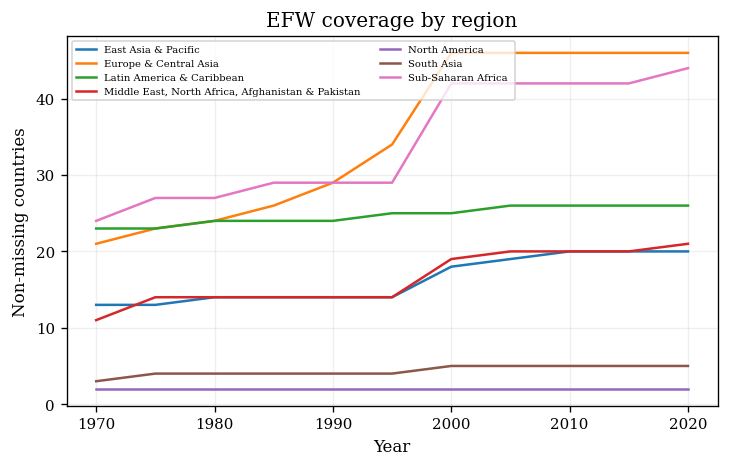

In [4]:
if "wb_region" in panel.columns and "efw_summary" in panel.columns:
    regional = (
        panel.groupby(["year", "wb_region"])["efw_summary"]
        .apply(lambda series: series.notna().sum())
        .reset_index(name="n_countries")
    )
    regional_pivot = regional.pivot(index="year", columns="wb_region", values="n_countries")
    display(regional_pivot.style.set_caption("EFW coverage by region"))
    fig, ax = plt.subplots(figsize=(7, 4))
    for region in sorted(regional["wb_region"].dropna().unique()):
        subset = regional[regional["wb_region"] == region]
        ax.plot(subset["year"], subset["n_countries"], label=region)
    ax.set_title("EFW coverage by region")
    ax.set_xlabel("Year")
    ax.set_ylabel("Non-missing countries")
    ax.legend(fontsize=6, ncol=2)
    display(fig)
    savefig(fig, OUTPUT_DIR / "figures" / "coverage" / "efw_coverage_by_region")
    plt.close(fig)

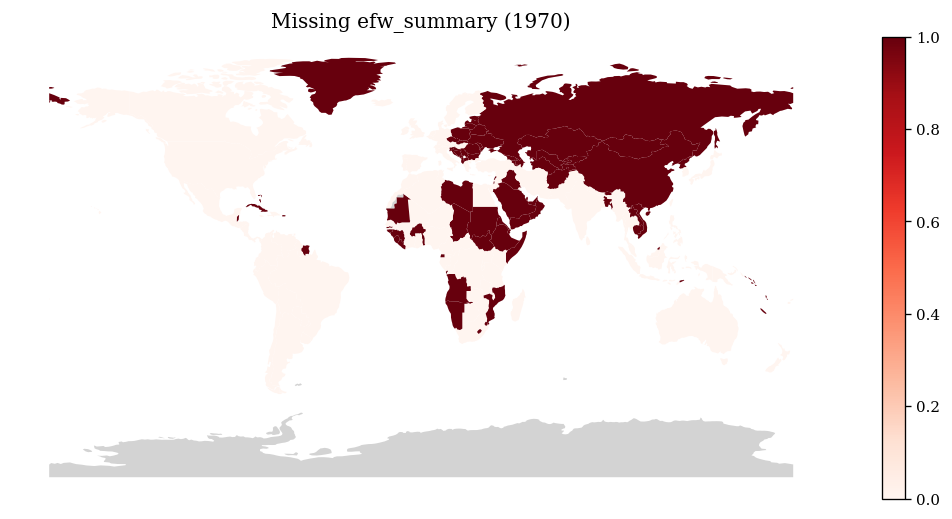

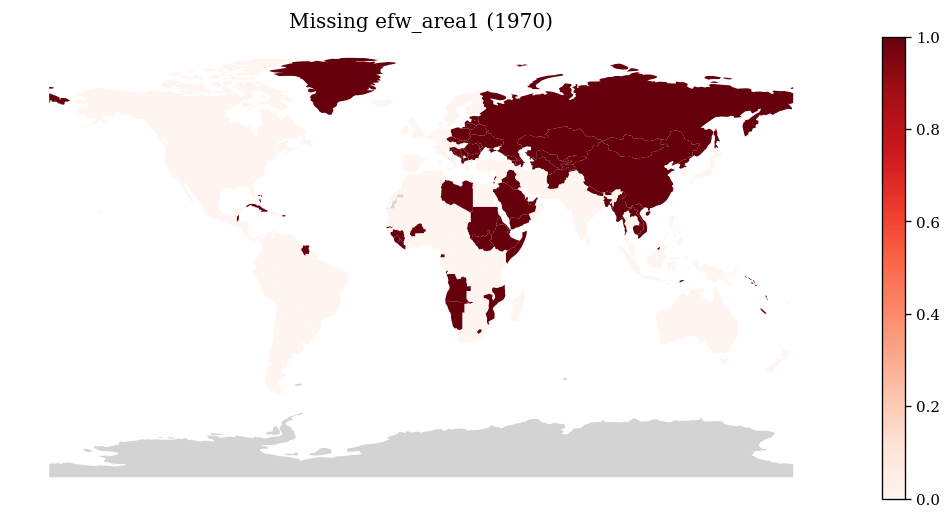

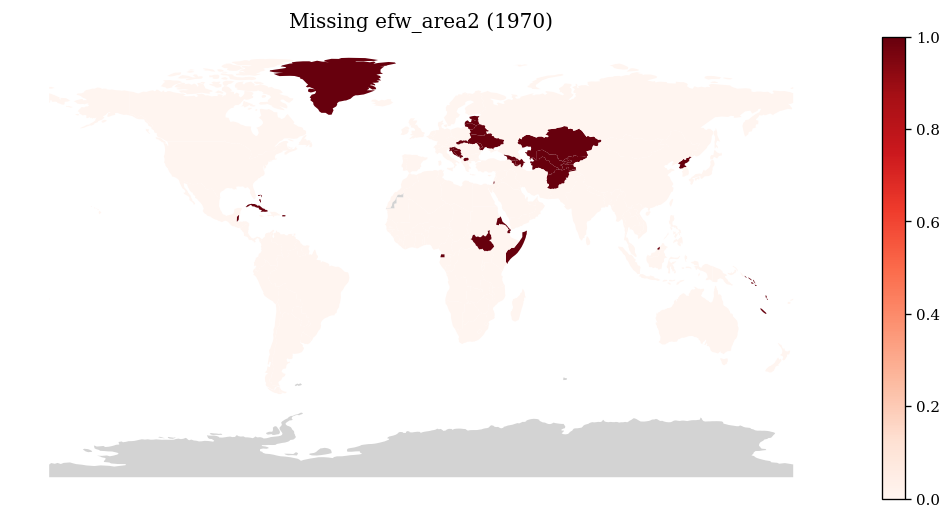

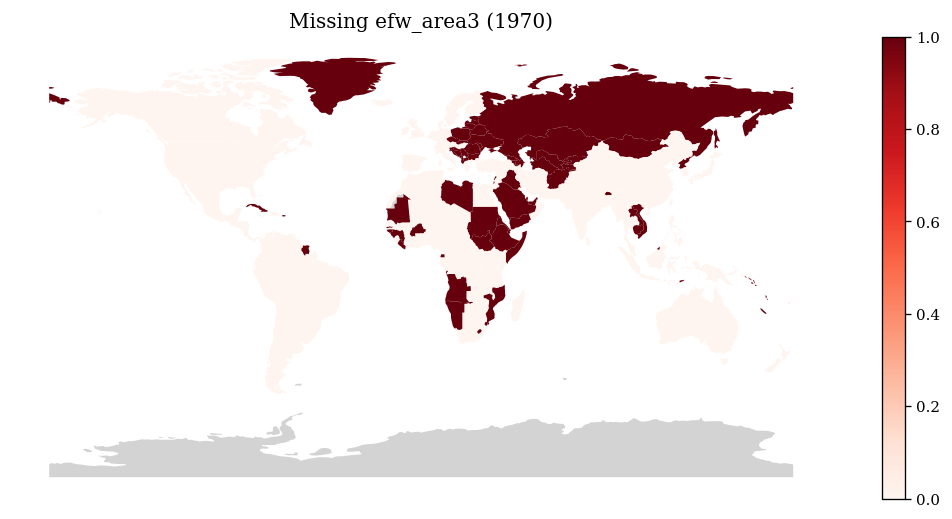

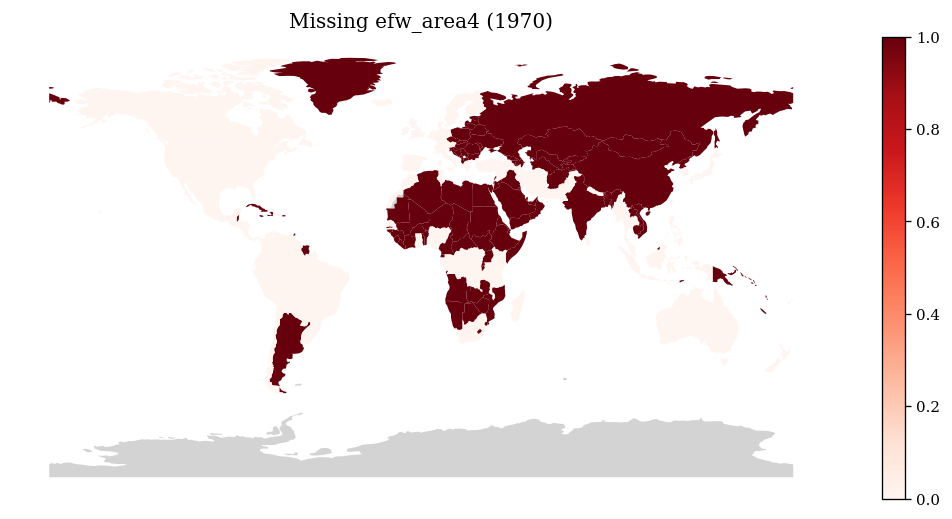

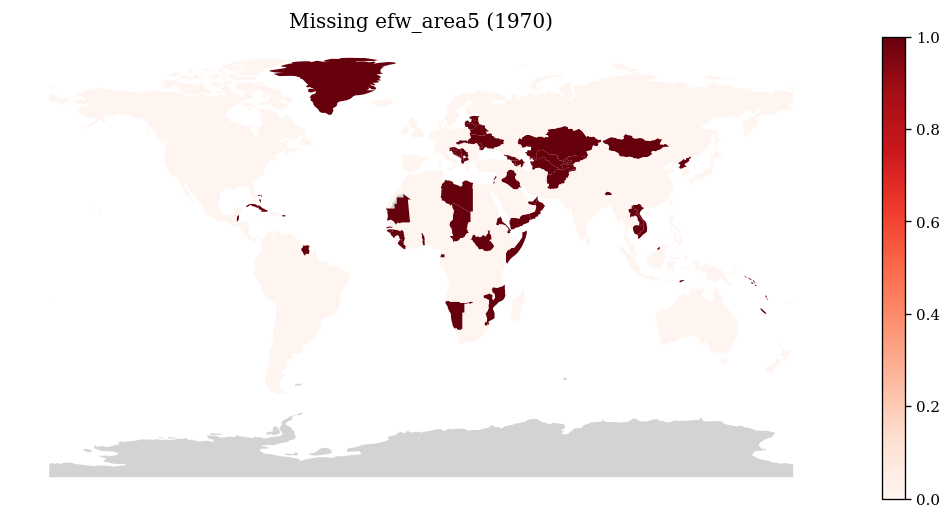

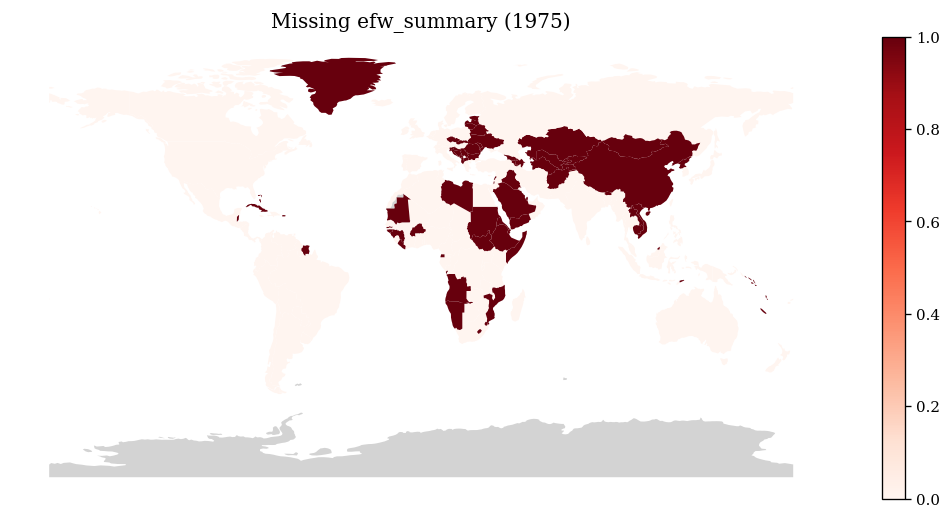

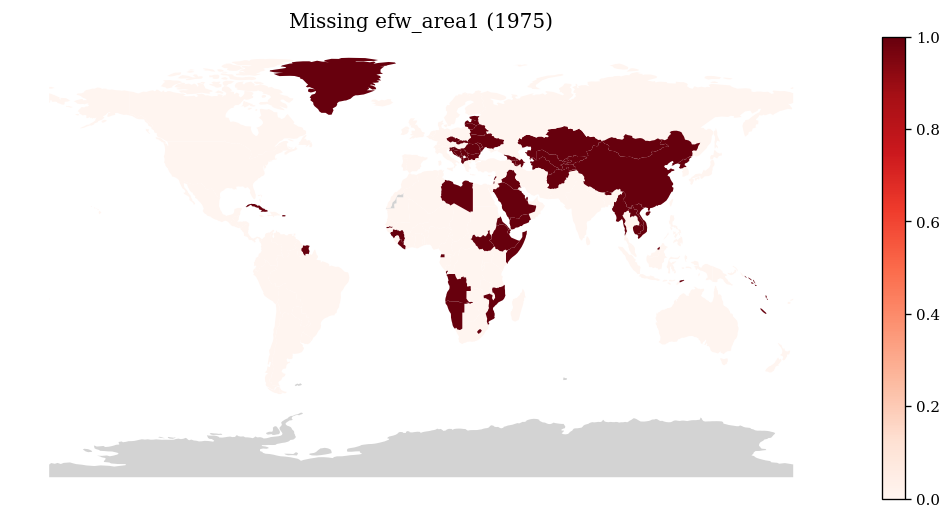

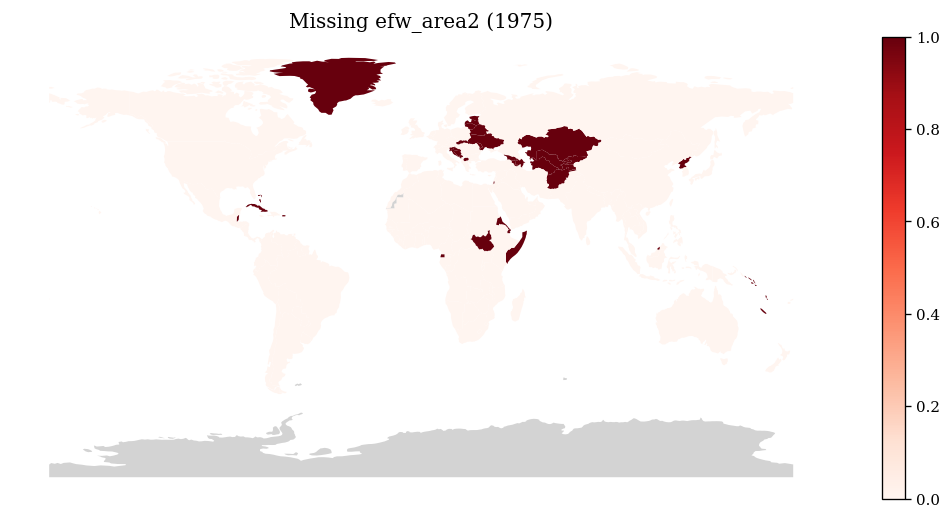

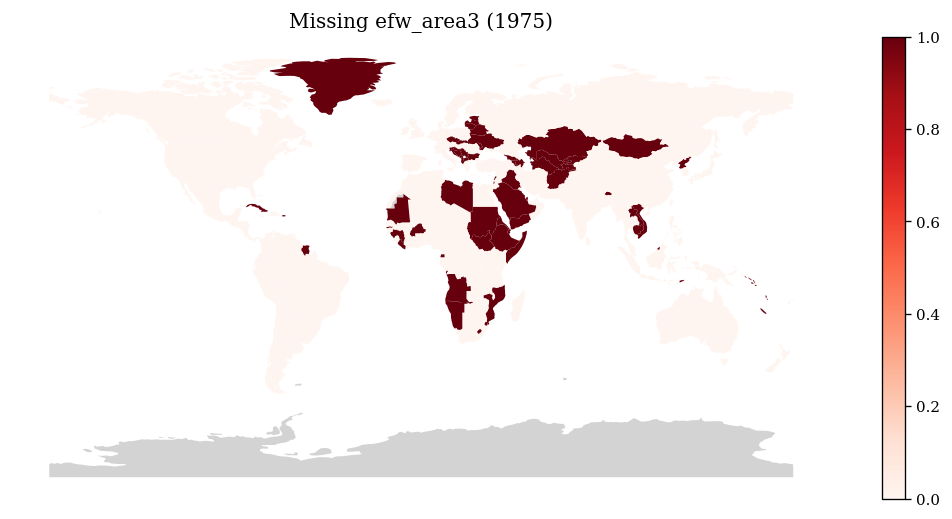

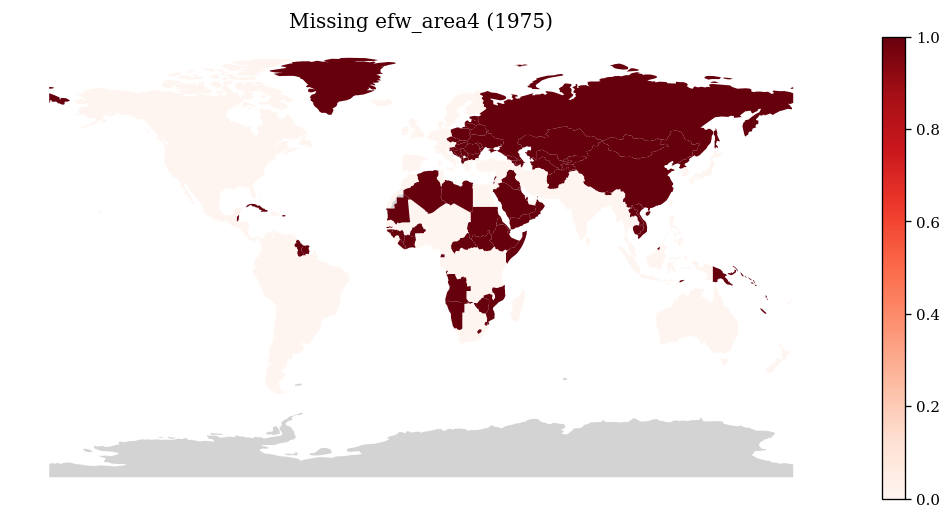

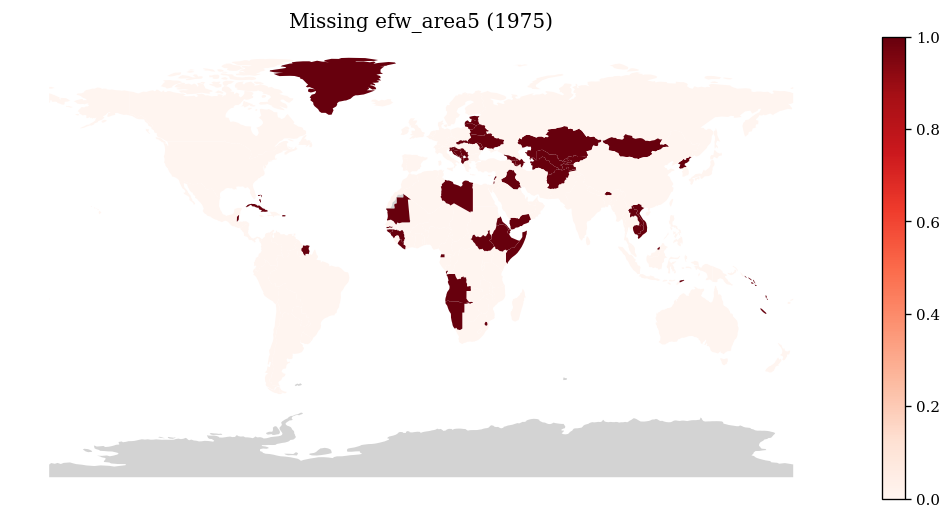

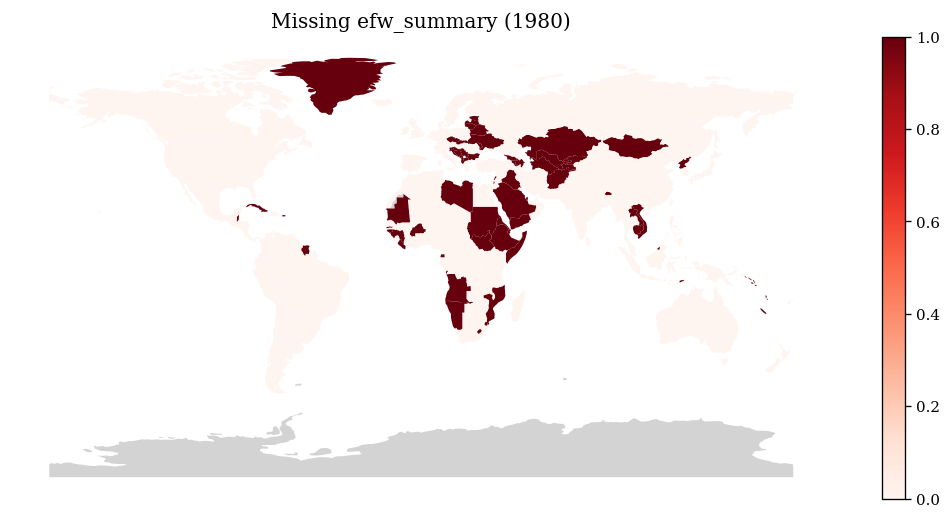

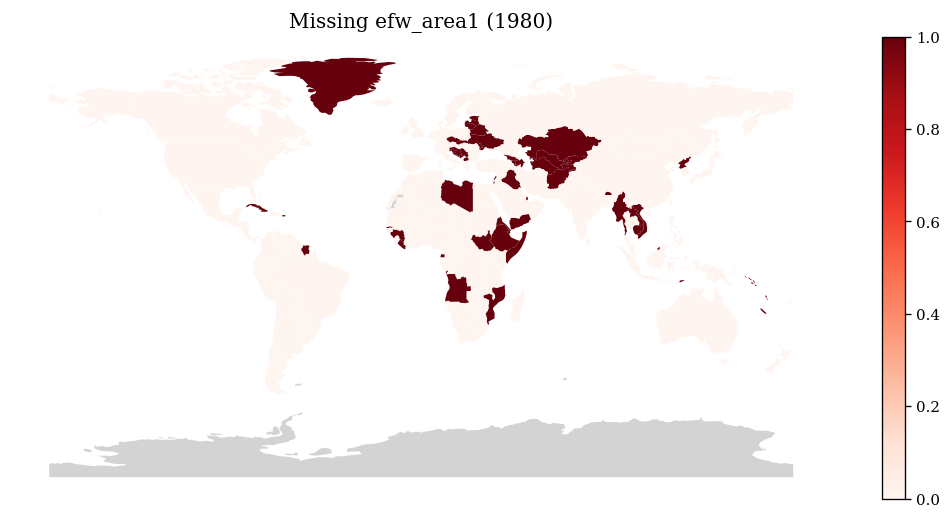

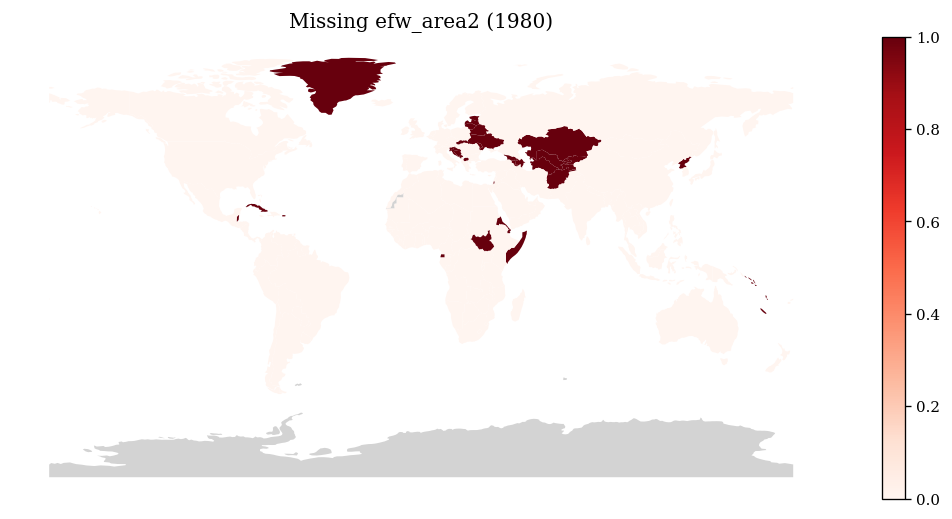

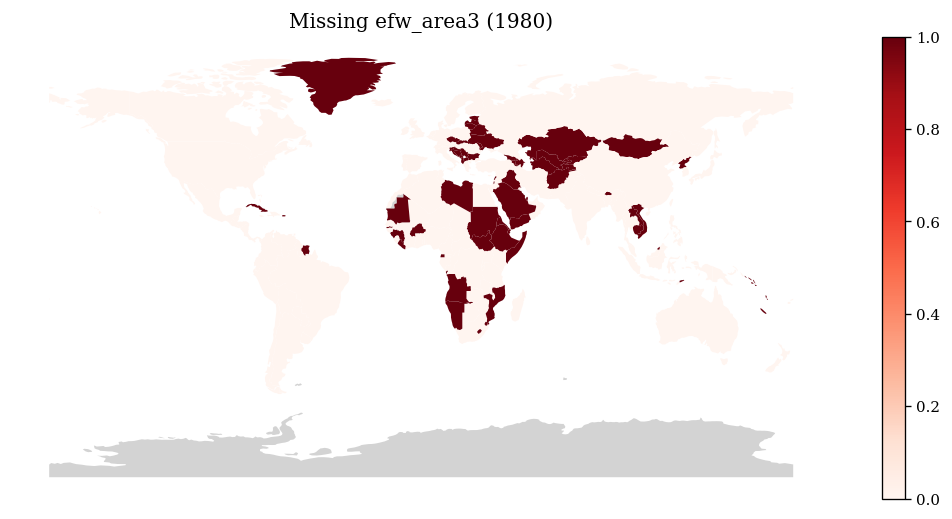

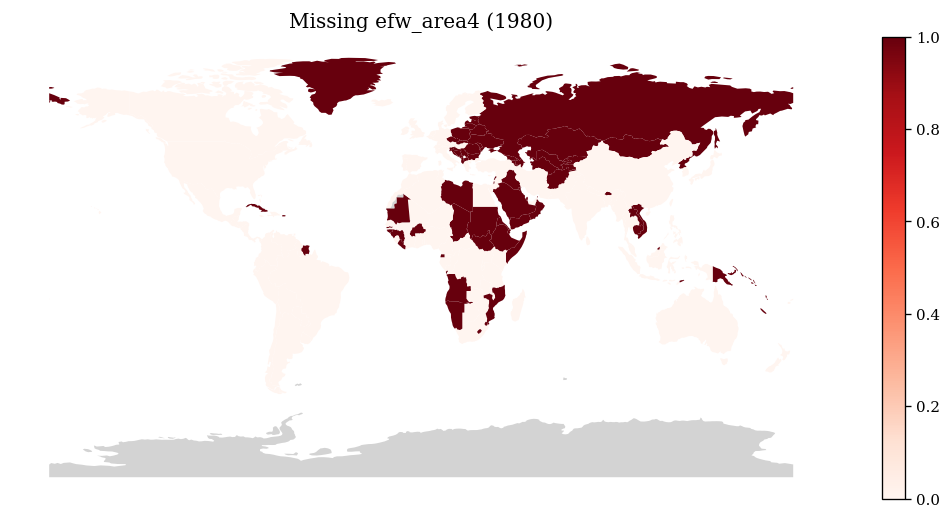

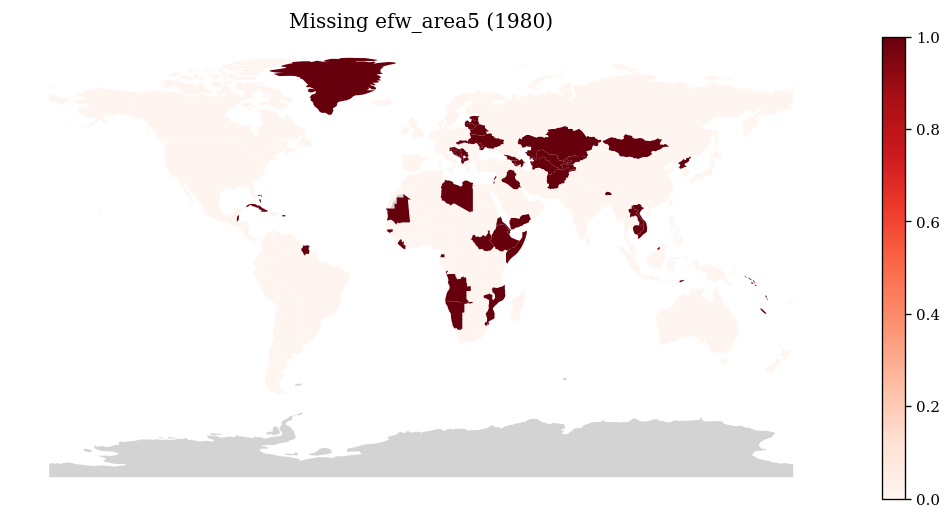

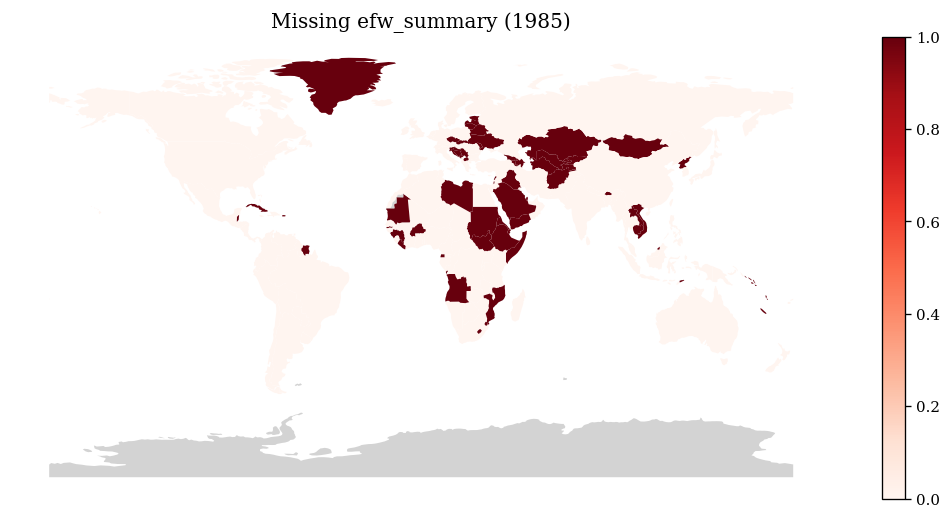

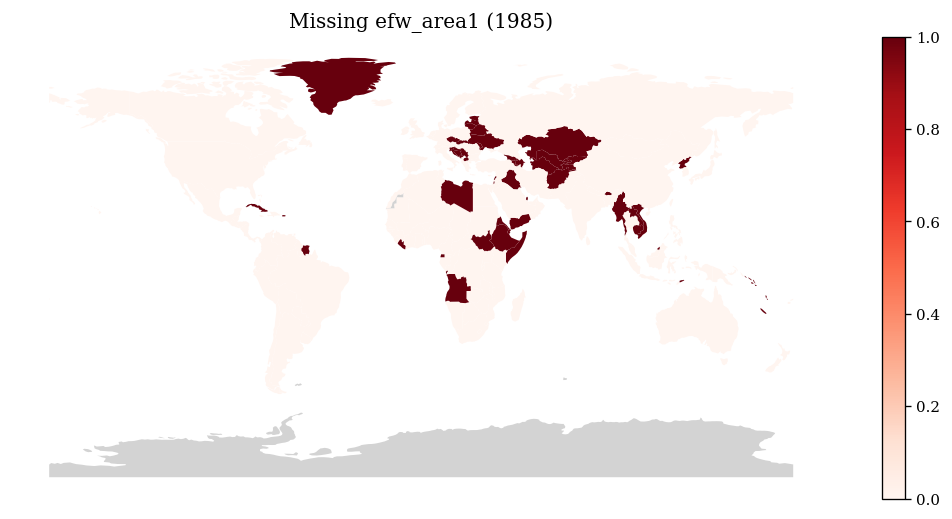

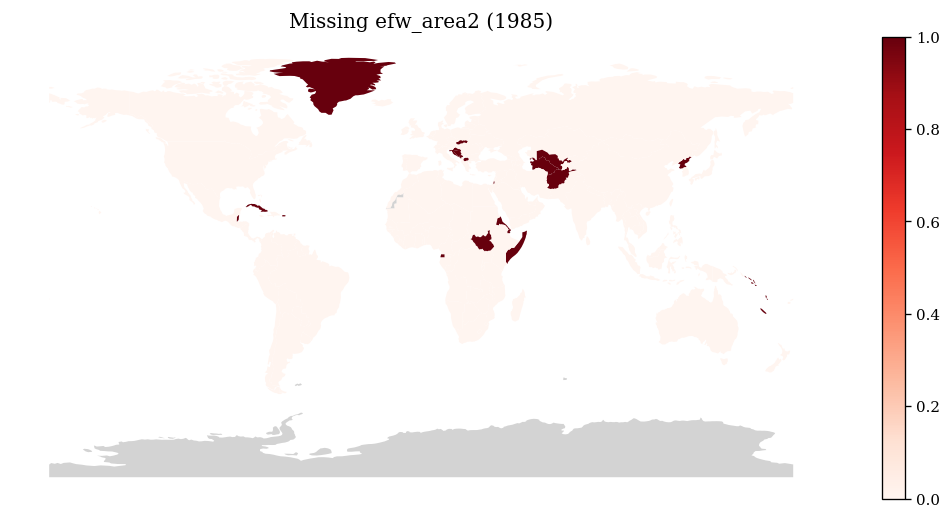

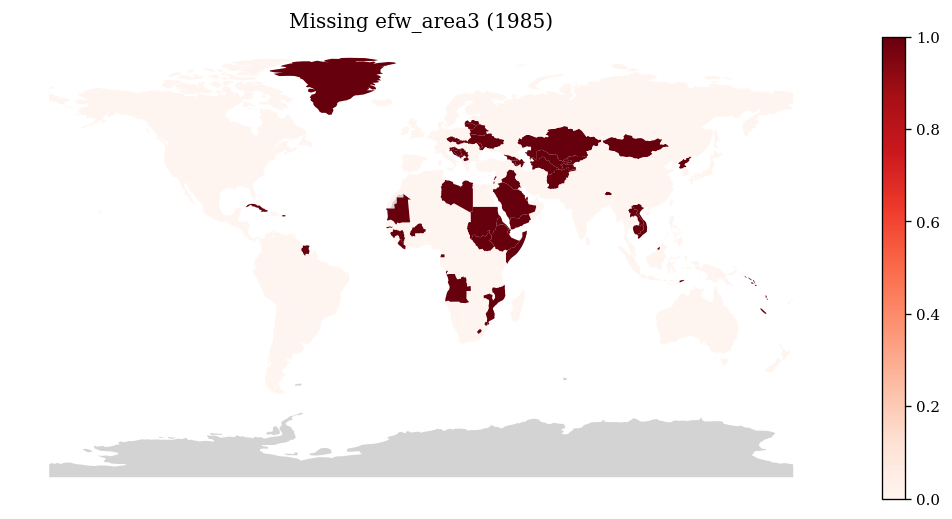

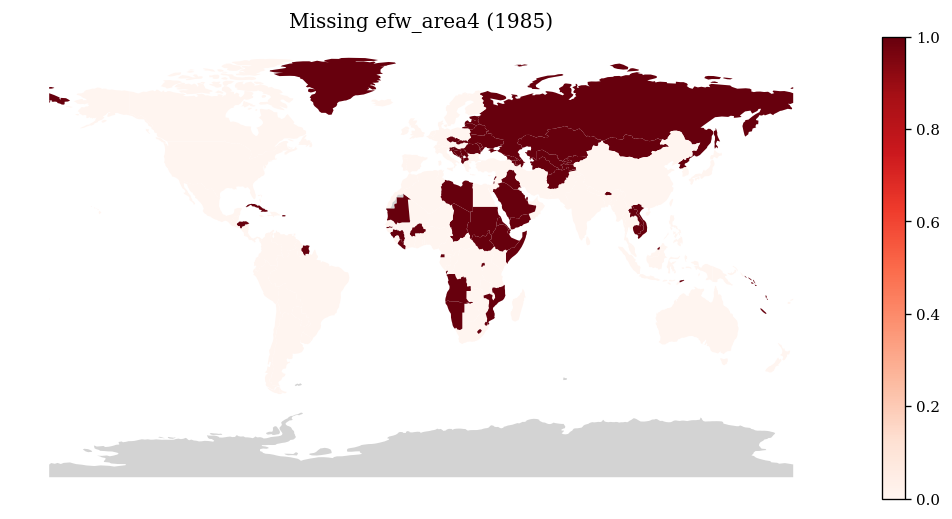

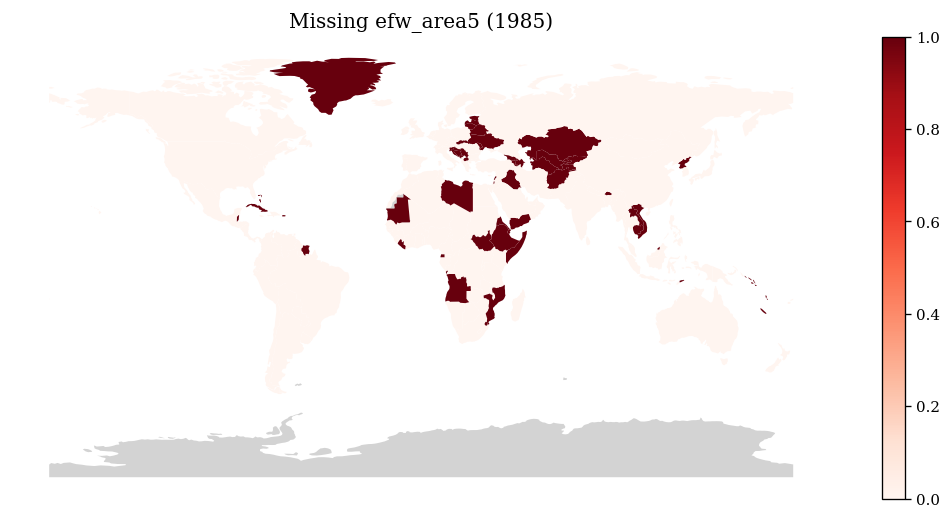

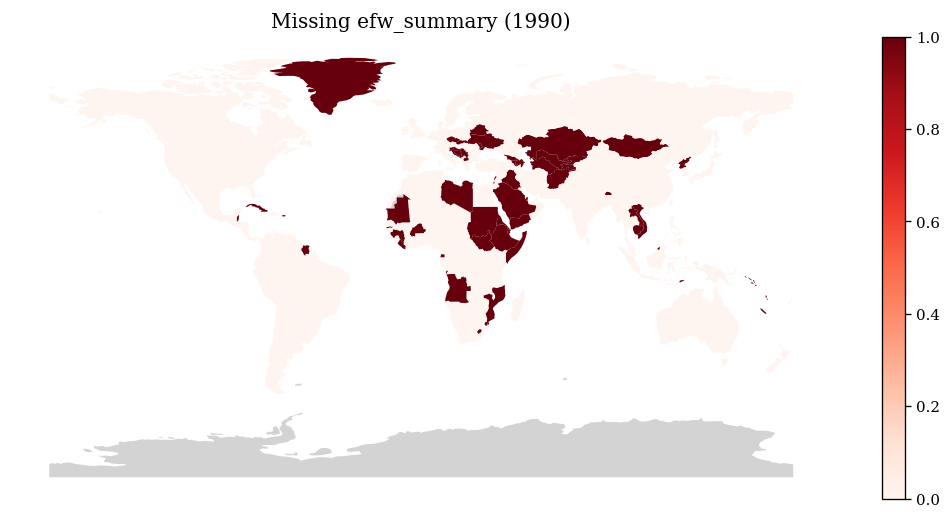

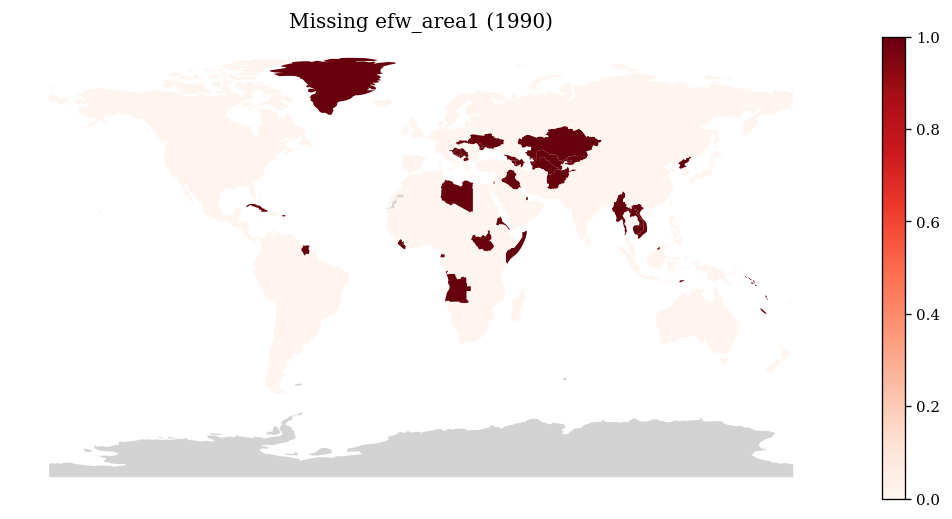

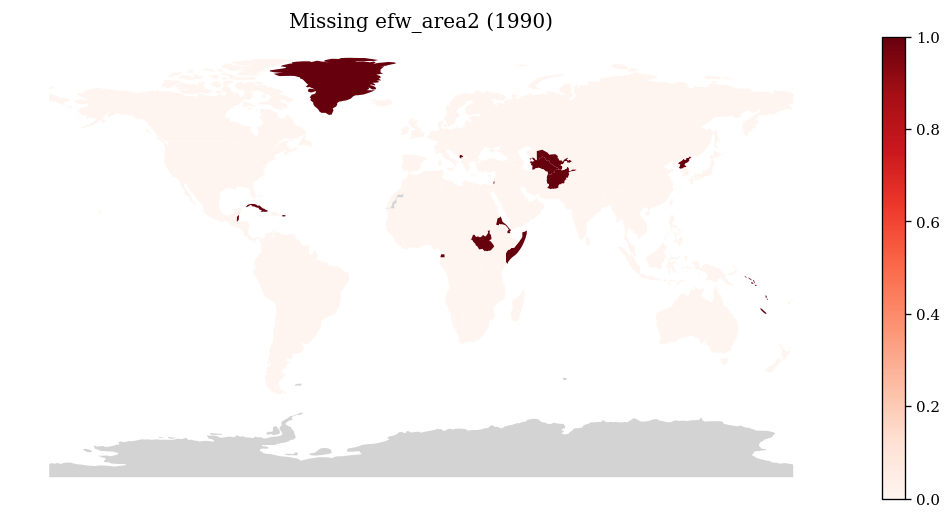

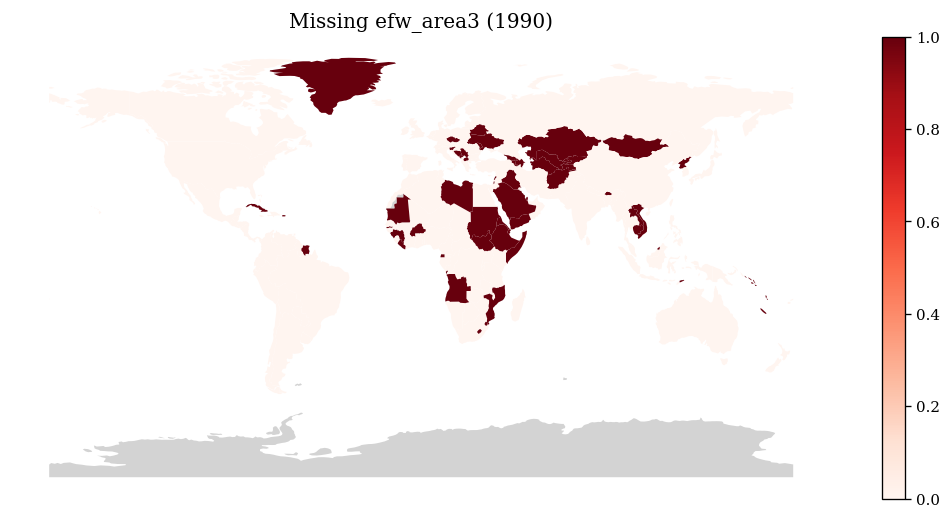

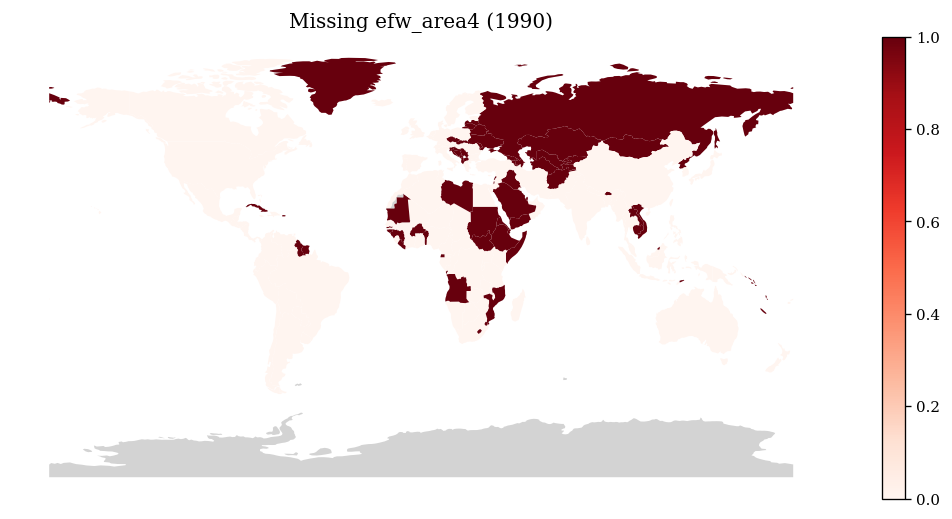

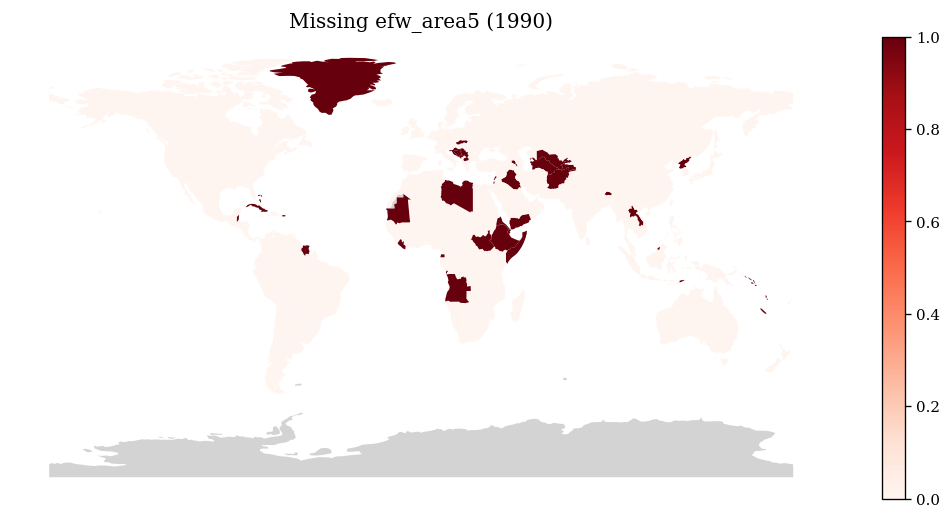

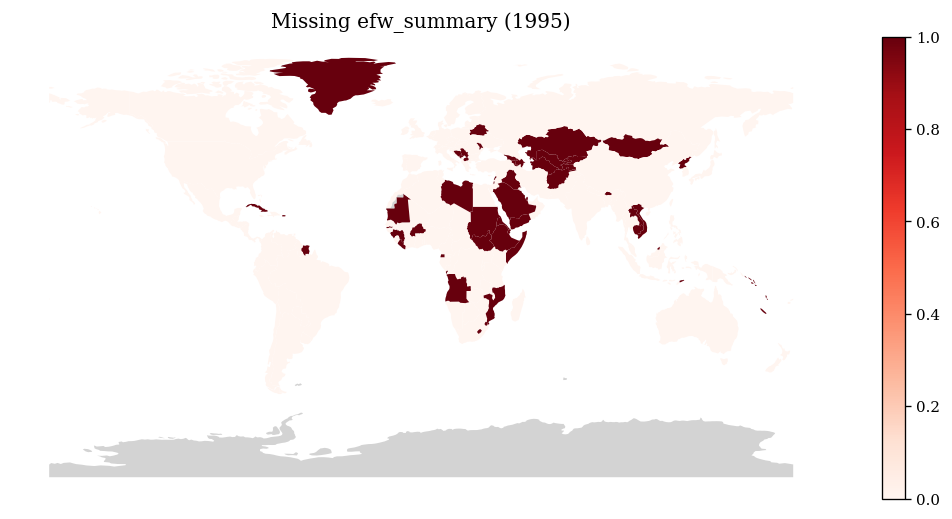

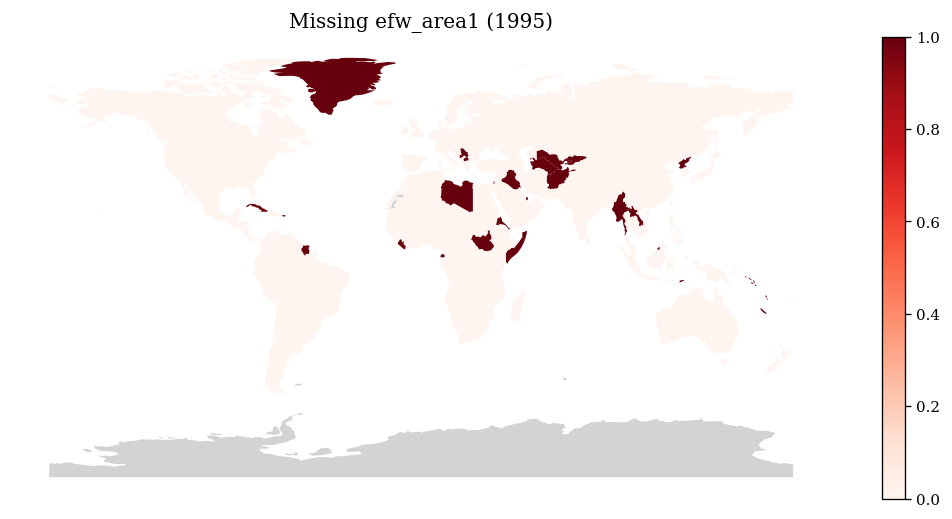

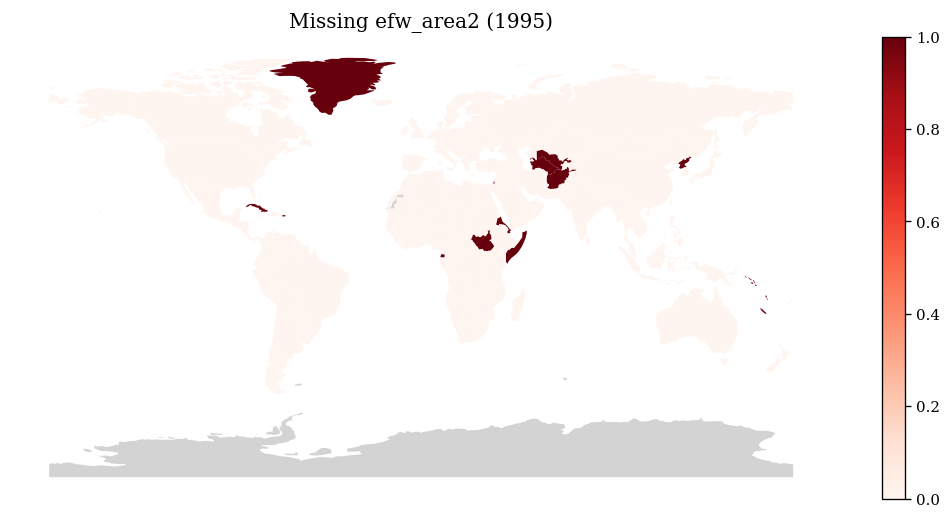

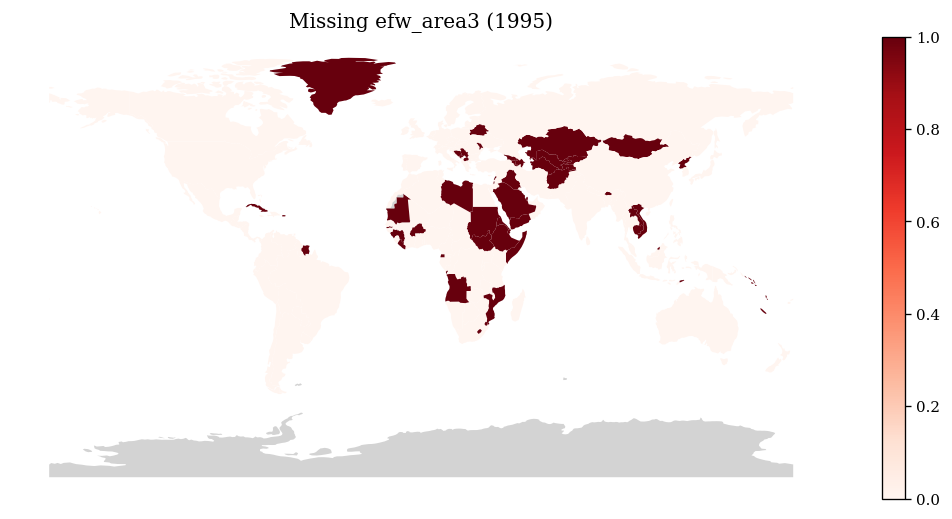

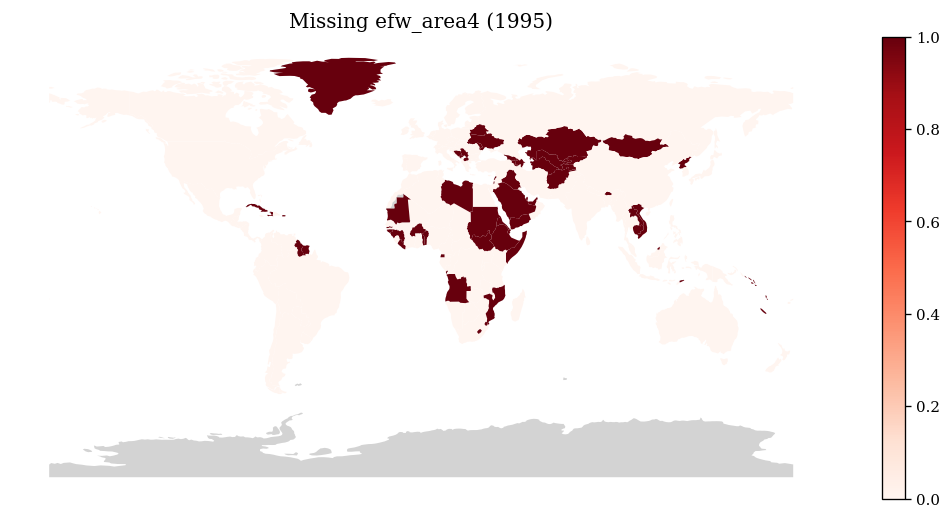

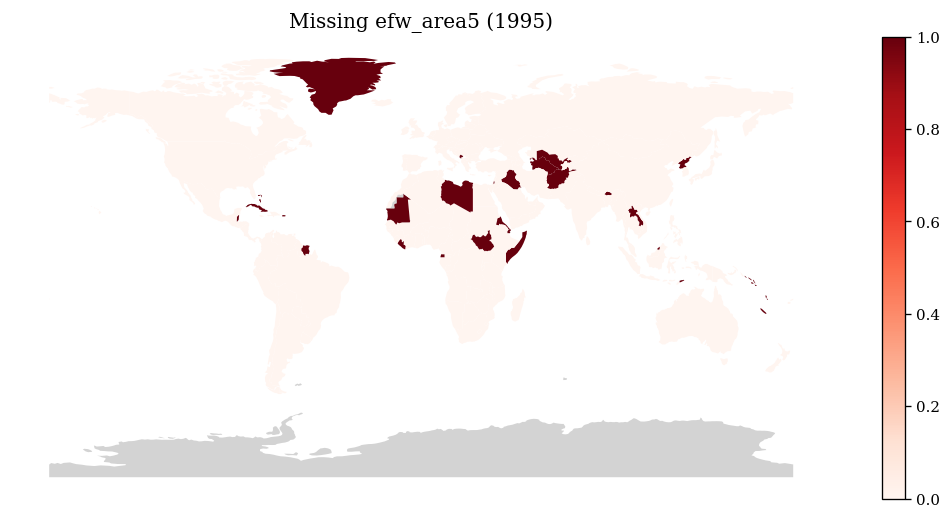

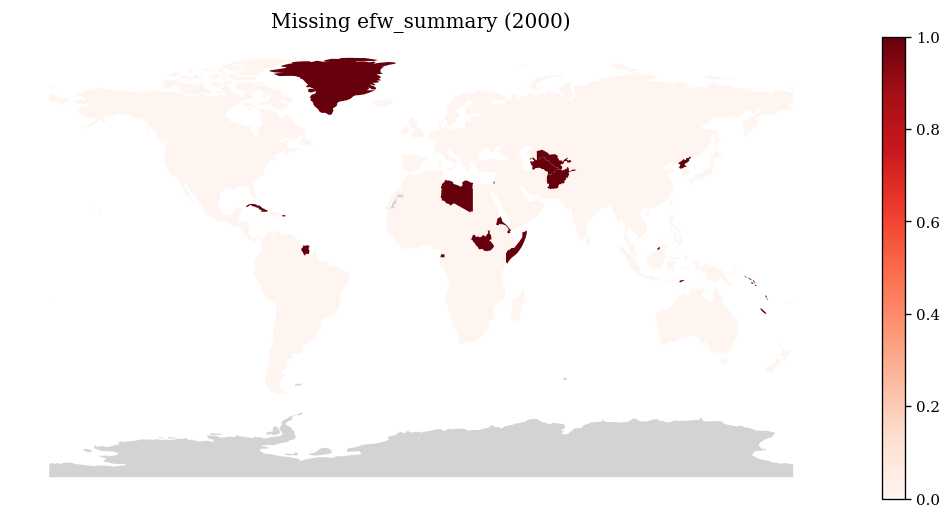

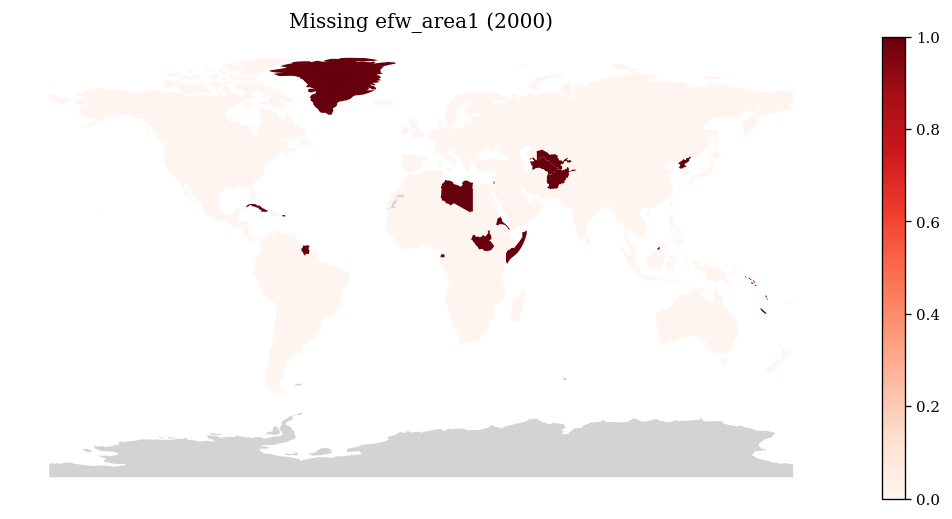

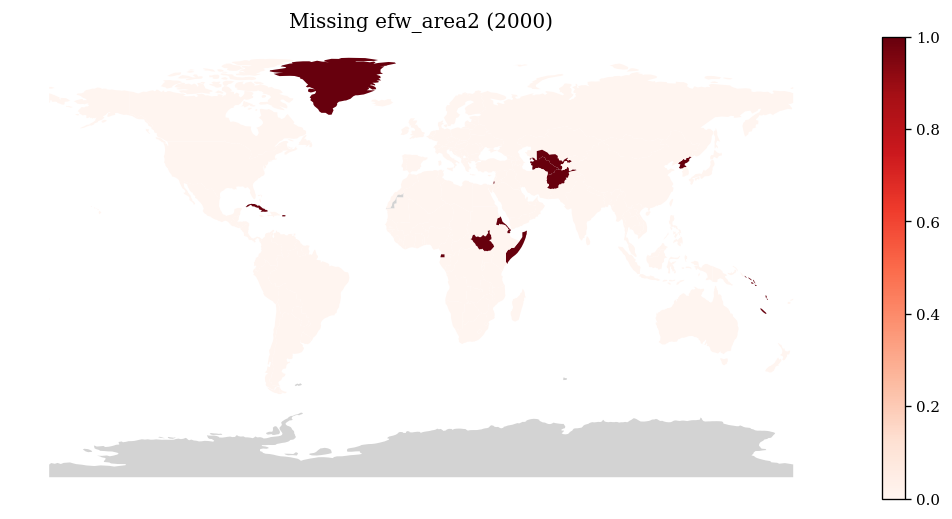

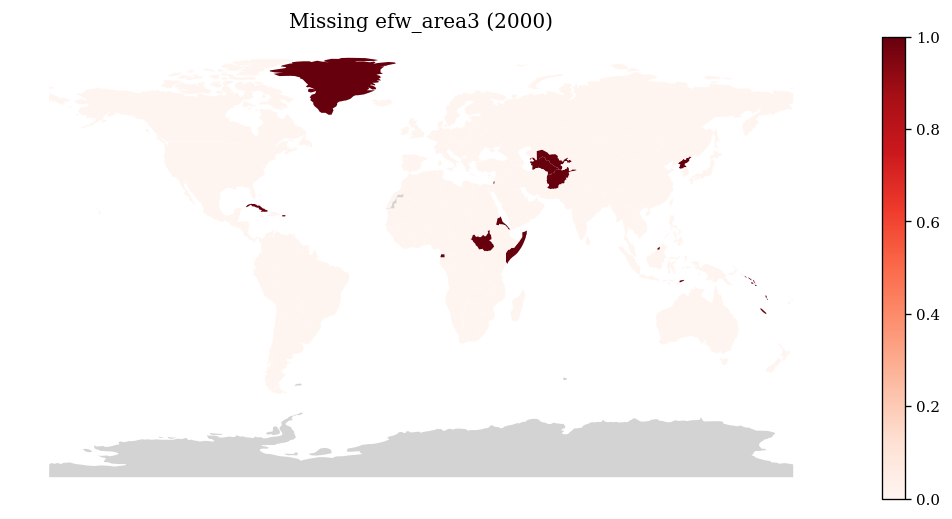

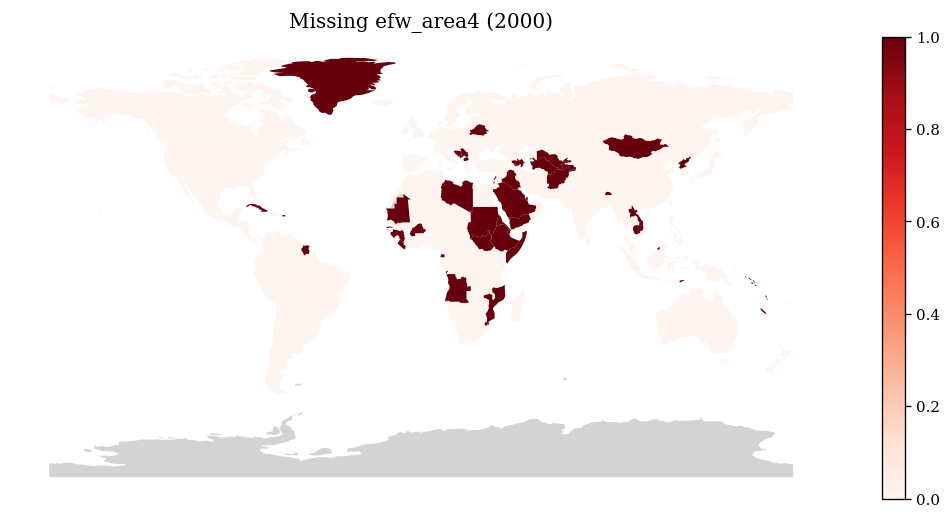

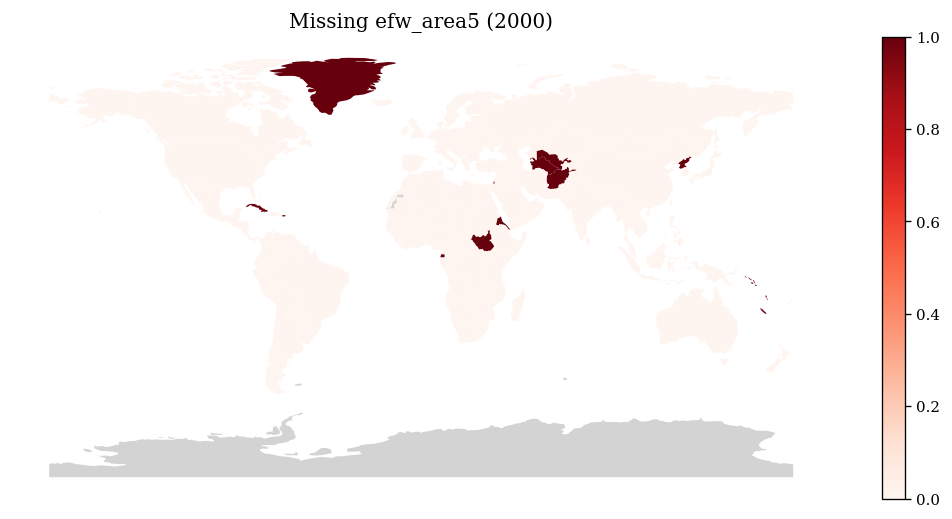

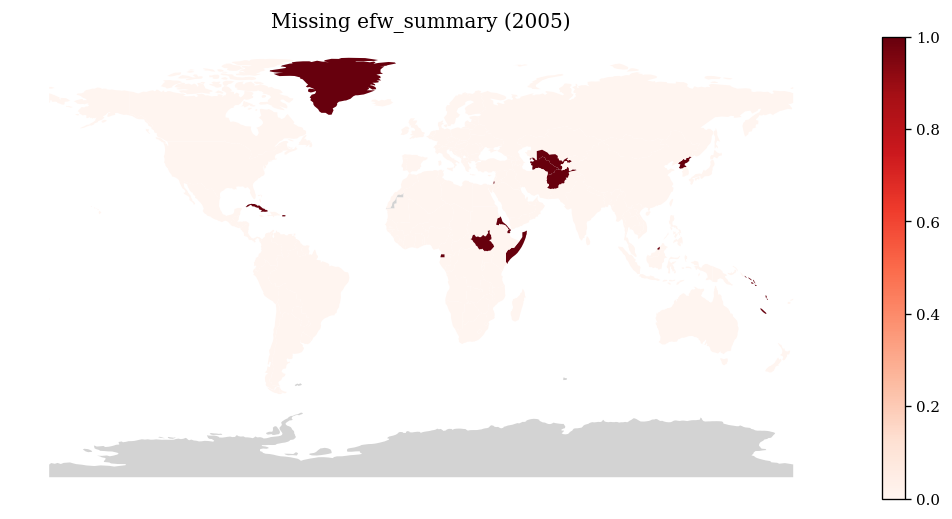

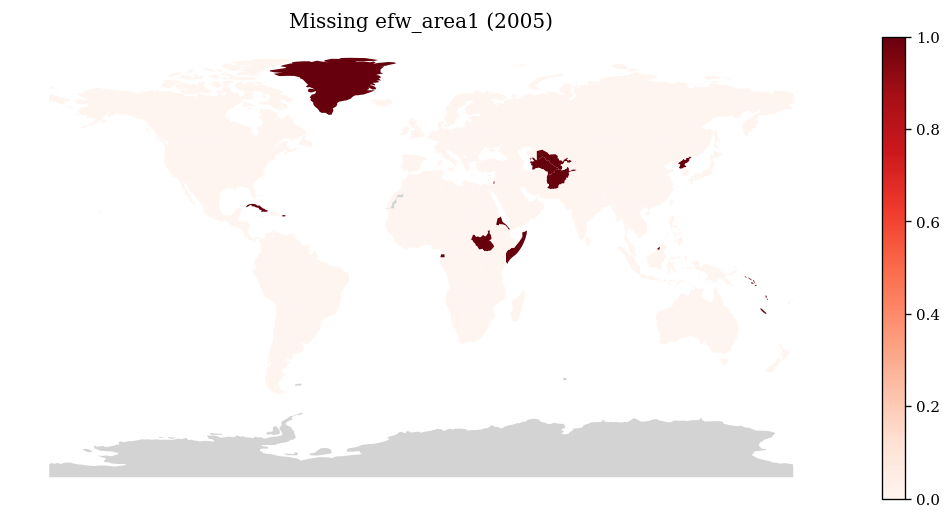

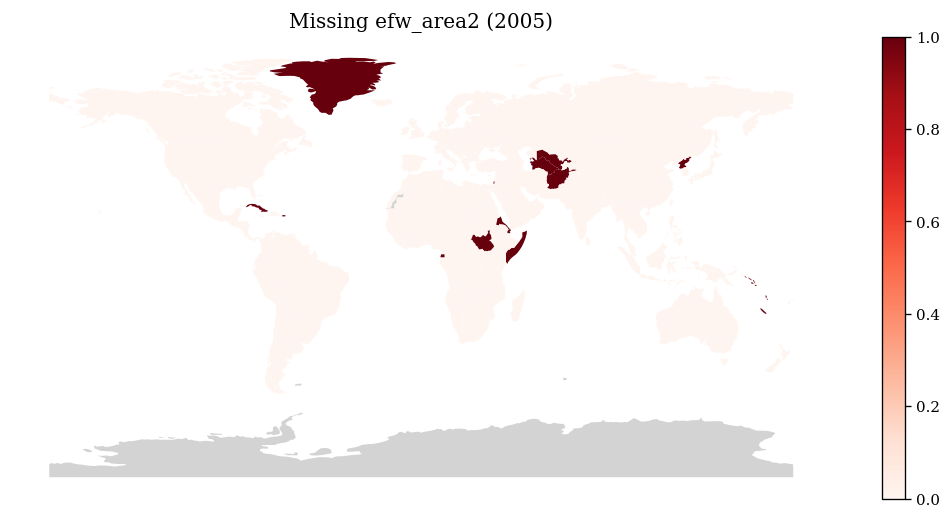

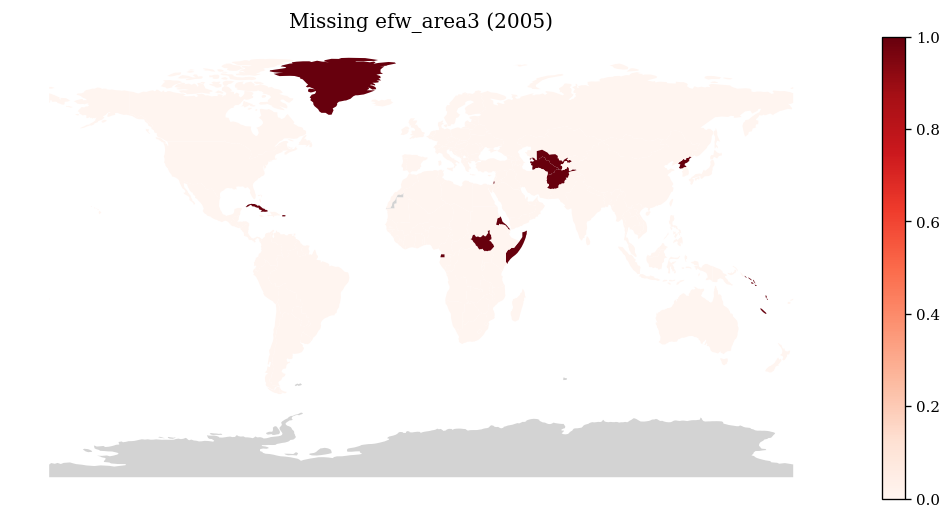

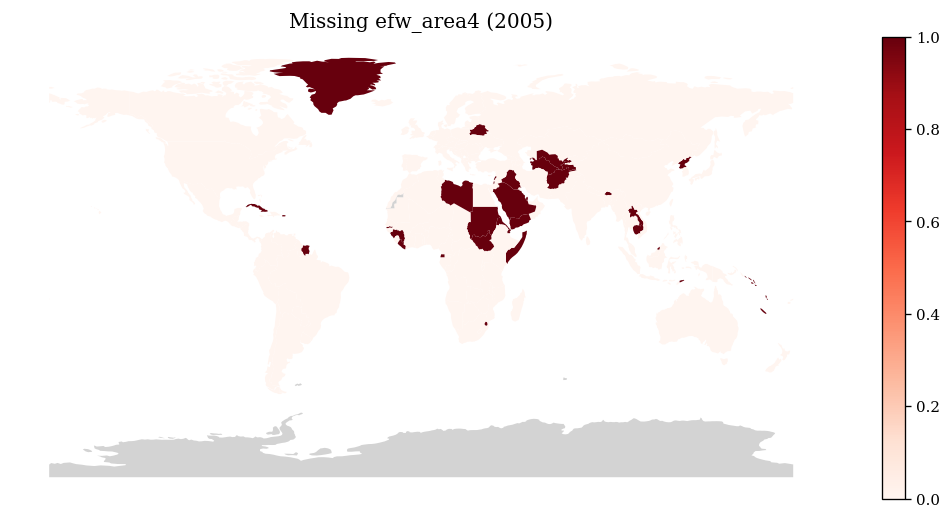

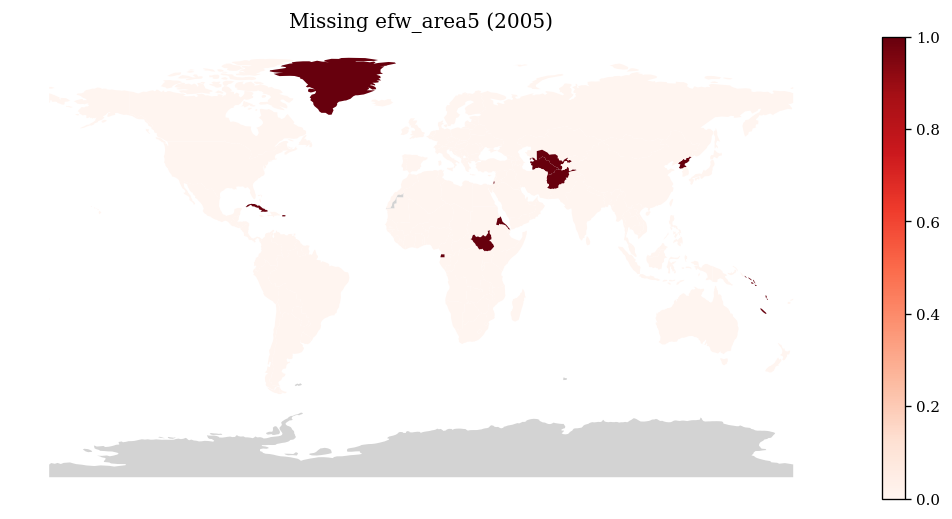

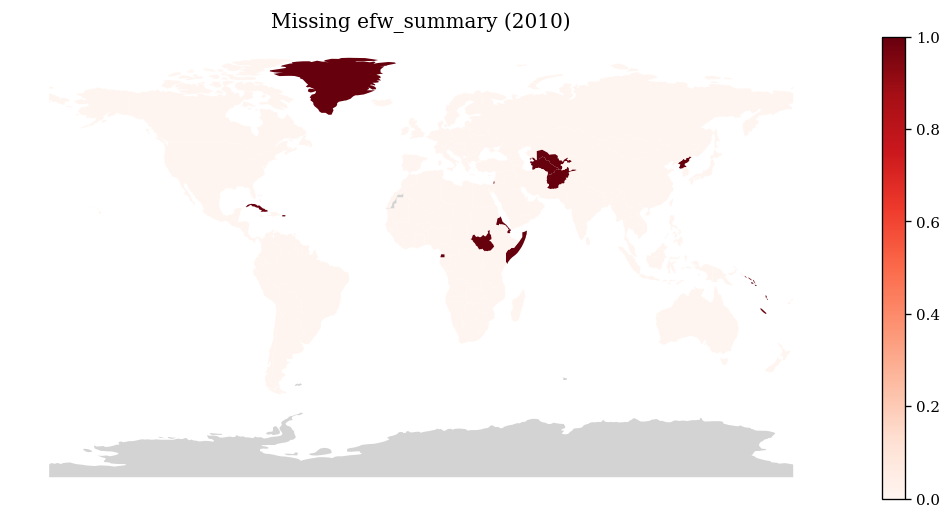

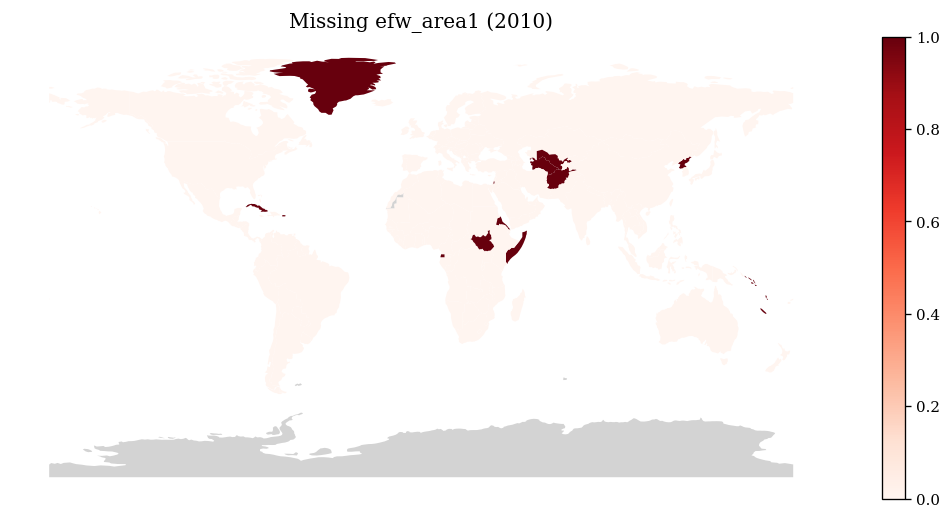

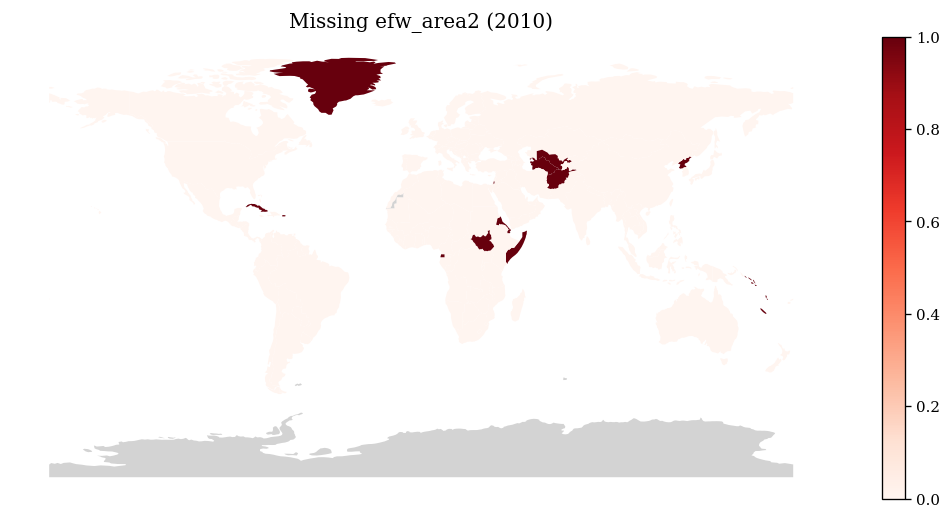

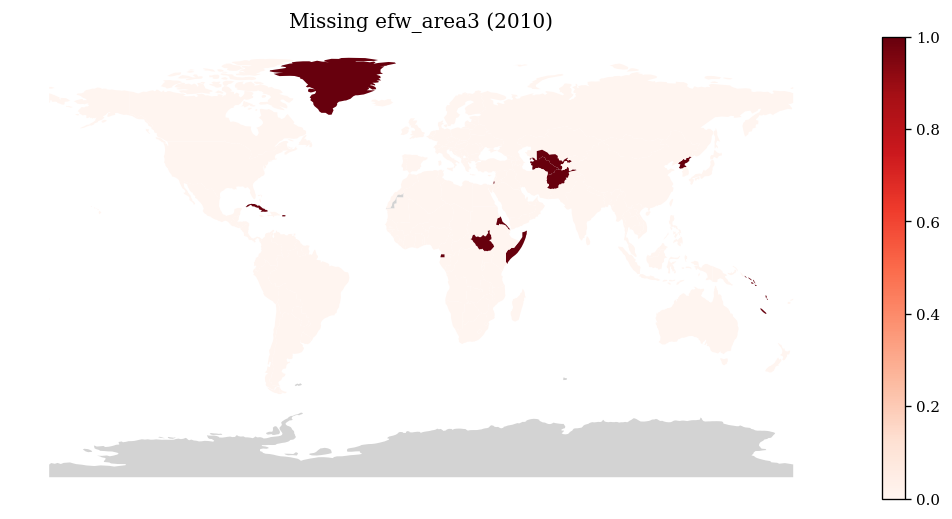

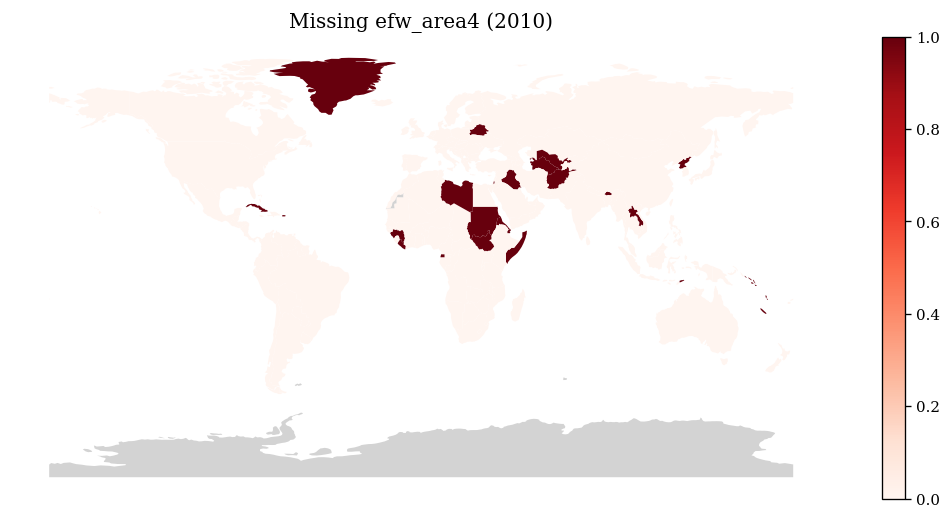

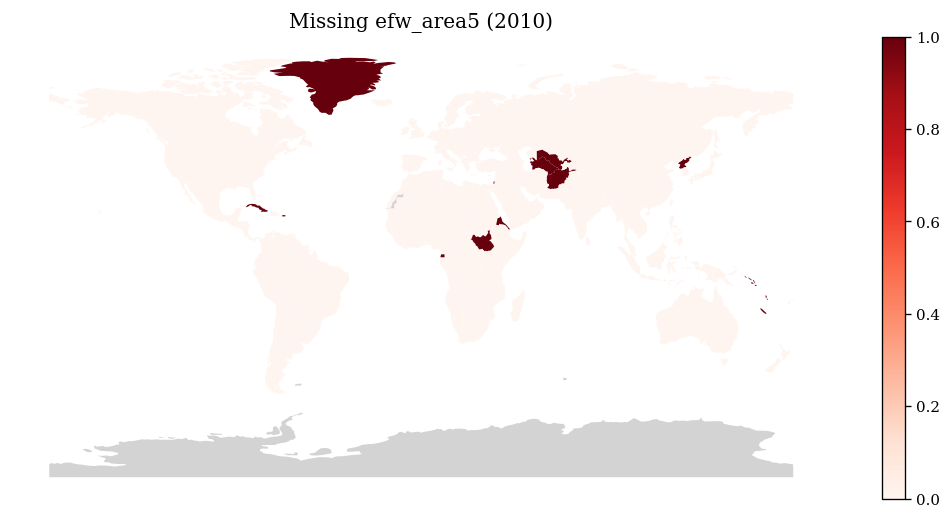

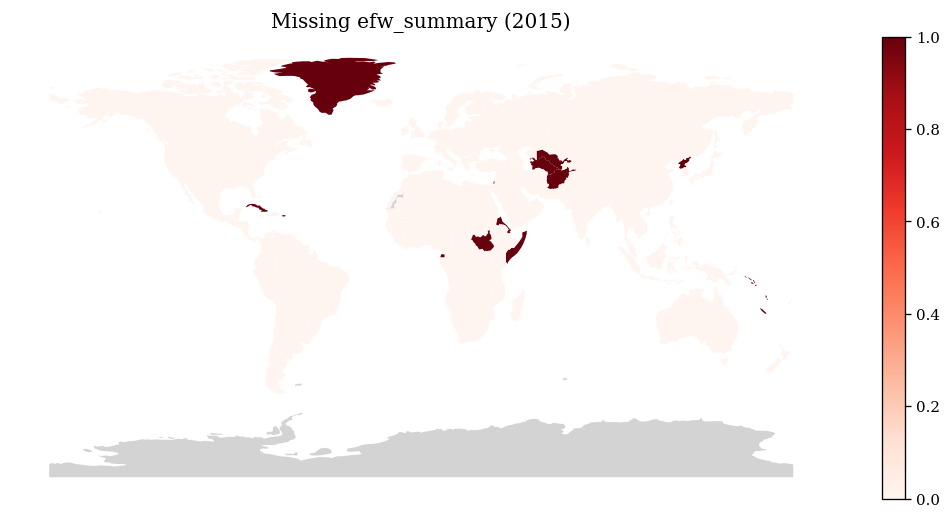

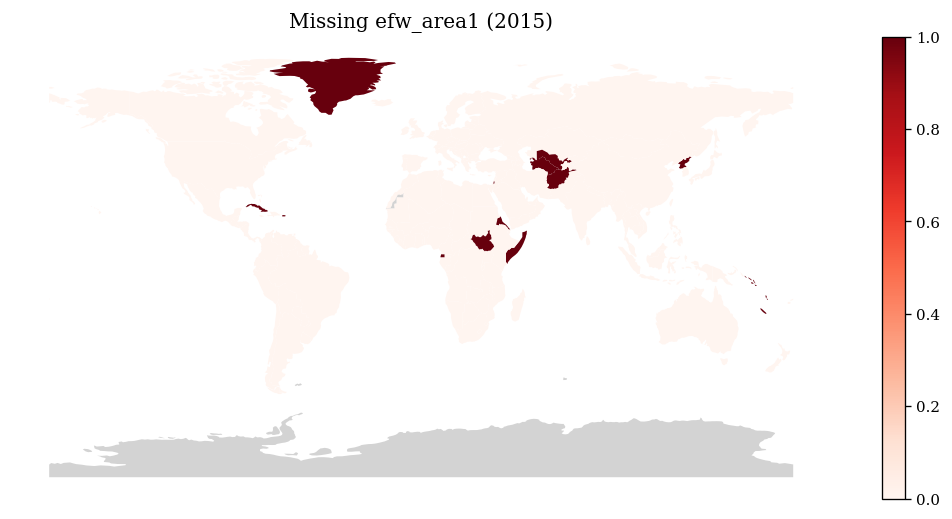

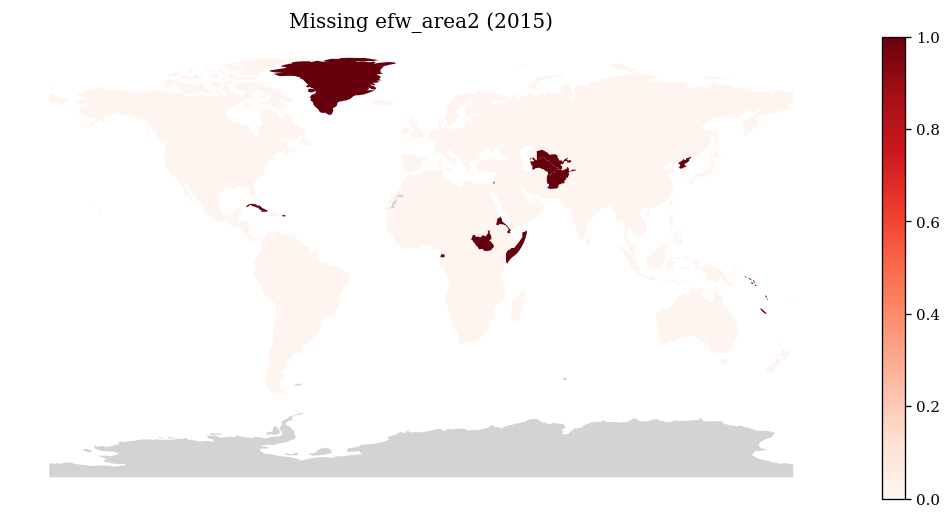

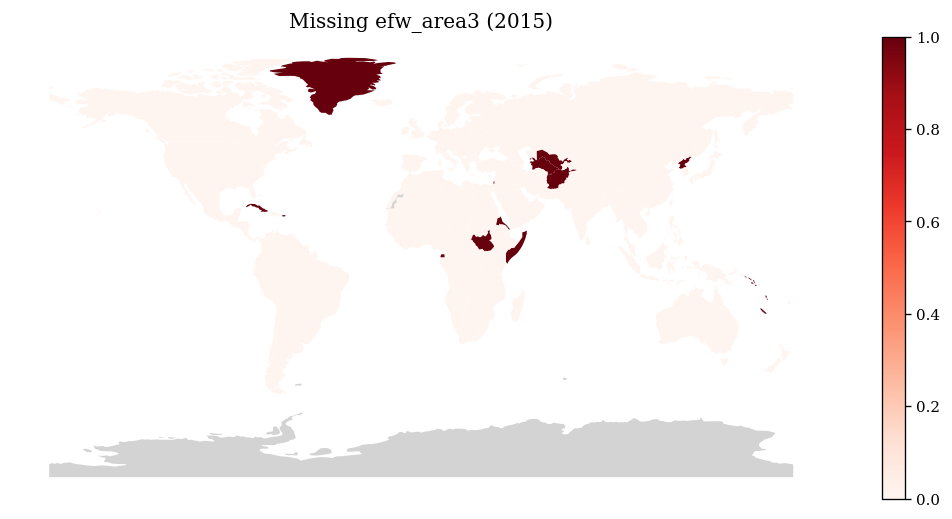

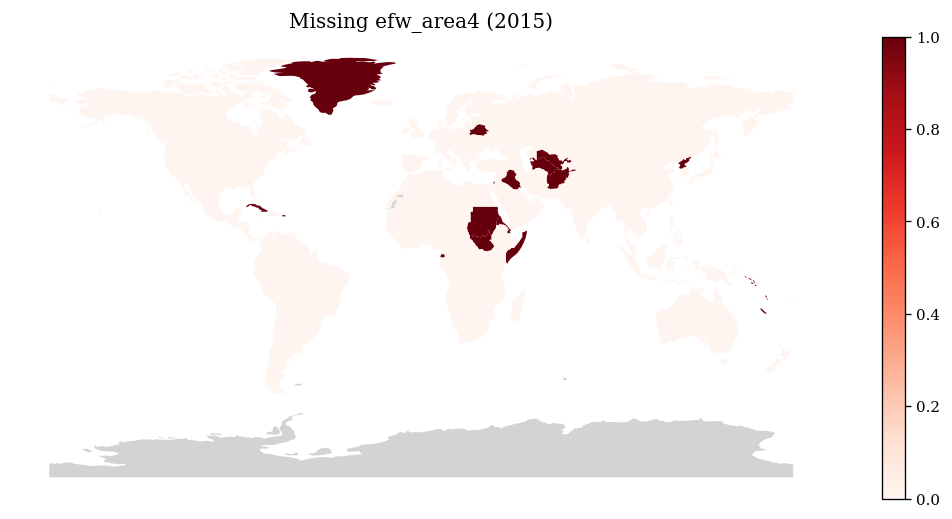

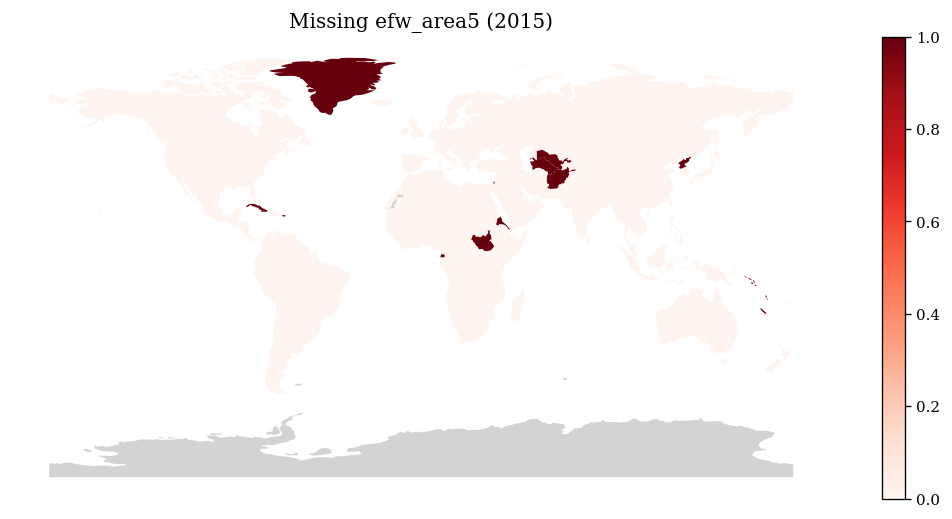

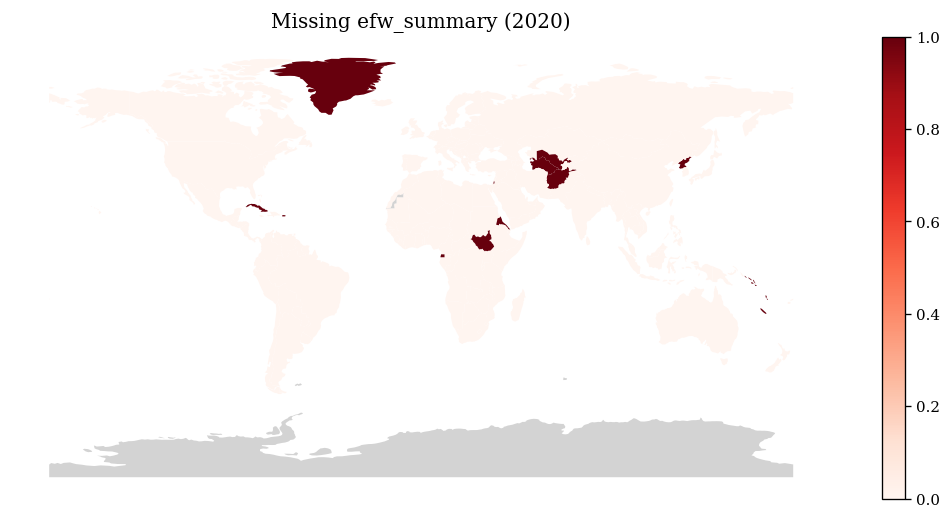

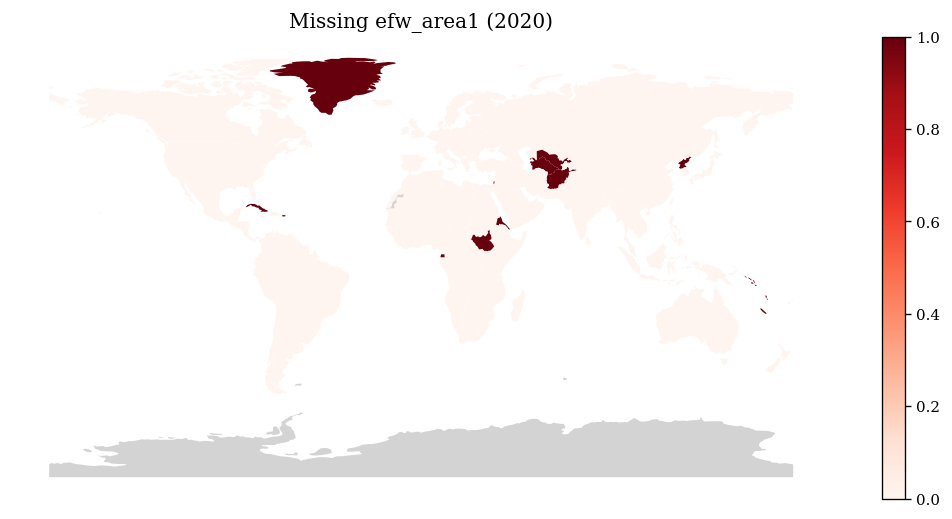

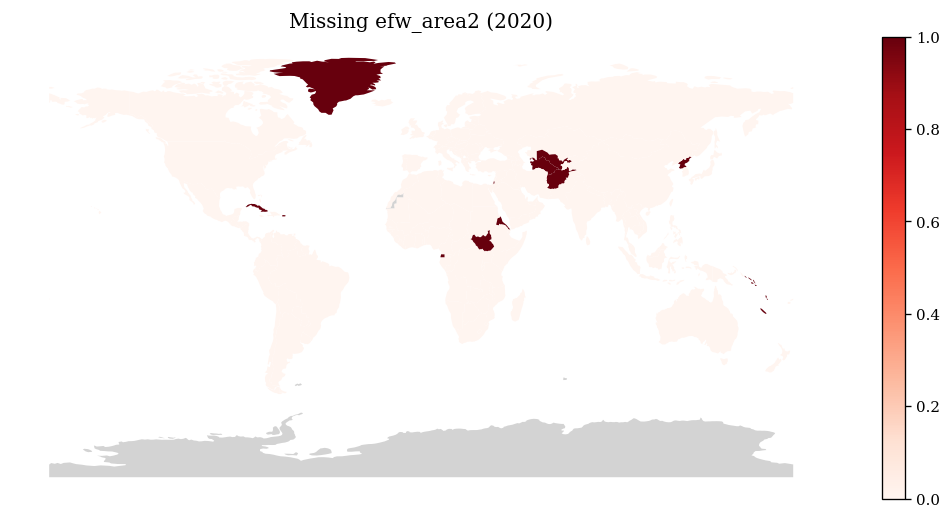

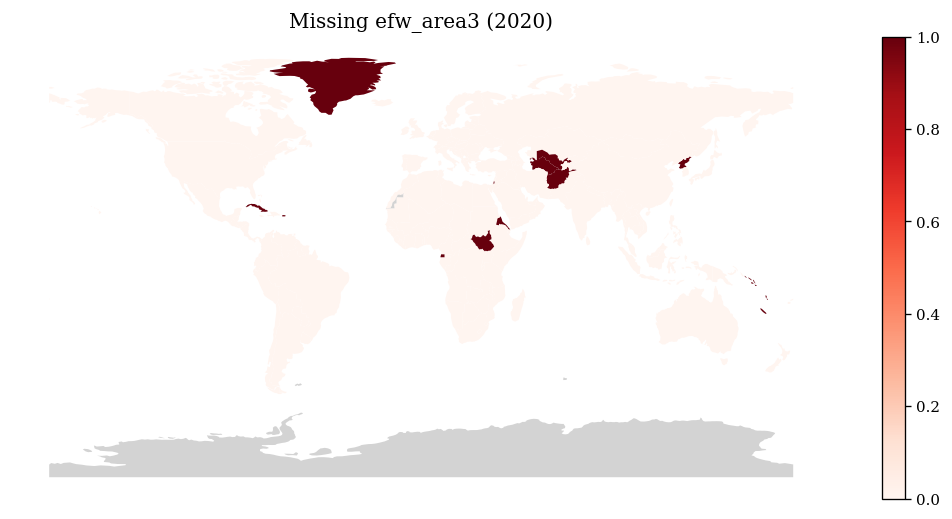

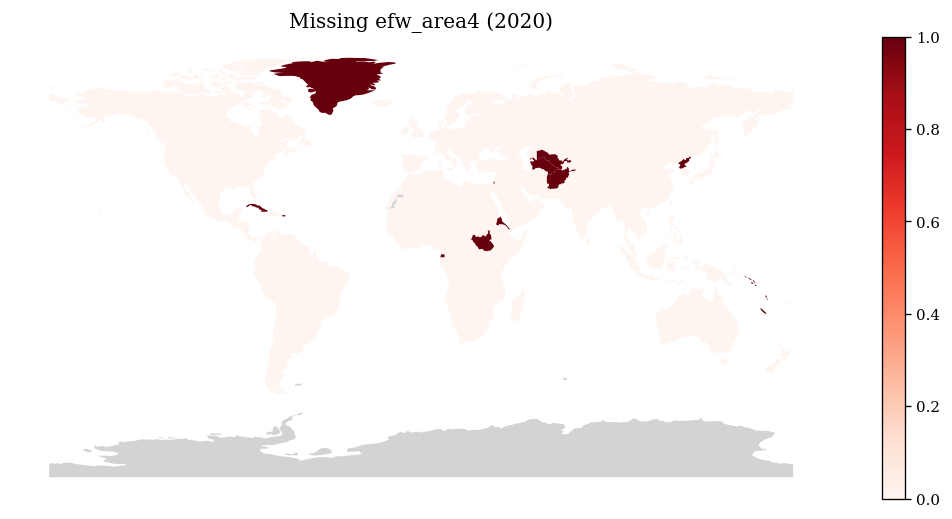

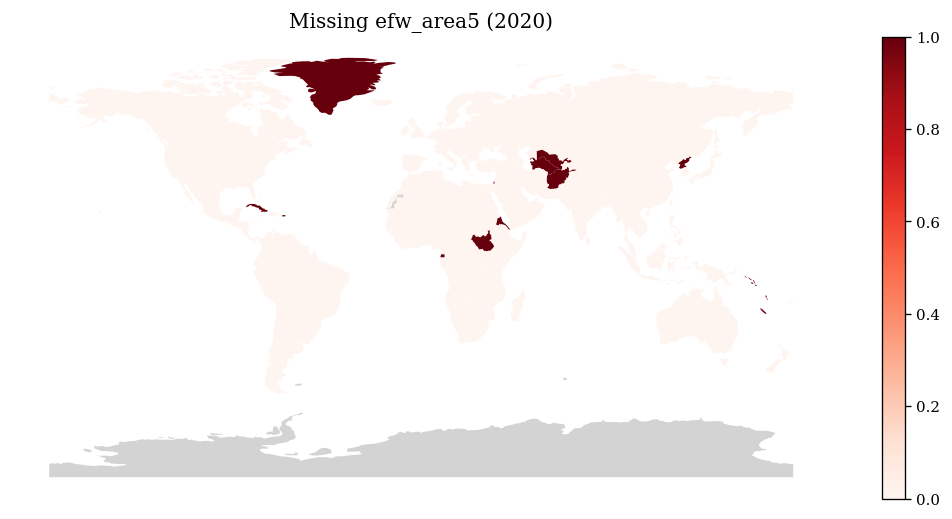

In [5]:
world = load_world_geometries()
missing_dir = OUTPUT_DIR / "figures" / "missingness_maps"
missing_dir.mkdir(parents=True, exist_ok=True)

for year in QUINQUENNIAL_YEARS:
    subset = panel[panel["year"] == year]
    for var in value_cols:
        missing = subset[["iso3c"]].copy()
        missing[var] = subset[var].isna().astype(int)
        merged = merge_world_data(world, missing, "iso3c", var)
        fig, _ = plot_choropleth(
            merged,
            var,
            title=f"Missing {var} ({year})",
            cmap="Reds",
            missing_color="lightgrey",
        )
        display(fig)
        savefig(fig, missing_dir / f"missing_{var}_{year}")
        plt.close(fig)

## Interpretation
Coverage varies across regions and income groups, with richer and larger
regions generally reporting more complete EFW data. In 2020, Europe &
Central Asia (46 countries) and Sub-Saharan Africa (44) have the broadest
coverage, followed by Latin America & Caribbean (26). The missingness maps
highlight geographic gaps that are concentrated in earlier years and in
lower-income regions, which is important for interpreting cross-country
comparisons in the subsequent notebooks.